# Análisis Estadístico de Ítems de Pedido (order_items.csv)
Este notebook analiza el archivo `order_items.csv`, que contiene el **detalle línea por línea**
de los productos incluidos en un conjunto de pedidos (ventas):con infromación detallada de cuánto se vendió, a qué precio, qué descuento se aplicó, cuánto costó el producto y cuánta ganancia (utilidad) dejó cada venta realizada

## 1. Importamos las librerías necesarias
Usamos `pandas` para manejar la tabla de datos, `scipy` y `scikit-posthocs` para las pruebas estadísticas, y `matplotlib`/`seaborn` para los gráficos.

In [2]:
# Librerías para manejar datos
import pandas as pd
import numpy as np

# Librerías para las pruebas estadísticas
from scipy import stats
import scikit_posthocs as sp

# Librerías para graficar
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Importamos la base de datos a analizar
Esta base de datos cuenta con la caractersitica de que se describen uno por uno los items de compra de un conjunto de facturas, por lo tanto Un mismo pedido (`order_id`) puede tener varias filas, una por cada item de producto que contiene.

In [3]:
df = pd.read_csv("C:\\Users\\kevin\\OneDrive\\Escritorio\\VISUAL ARCHIVOS\\Datos estructurados y no estructurados\\order_items.csv")
df

,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
0,ORD-301242,PROD-000738,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12
1,ORD-301242,PROD-000181,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92
2,ORD-773460,PROD-000973,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84
3,ORD-773460,PROD-000268,4,31.36,0.336182,42.17,125.44,15.82,0.00,99.09,55.72,43.37
4,ORD-449374,PROD-001040,3,6.31,0.089678,1.70,18.93,1.21,0.98,19.42,5.91,12.53
...,...,...,...,...,...,...,...,...,...,...,...,...
397564,ORD-252033,PROD-000792,2,137.53,0.156007,42.91,275.06,16.25,6.21,254.61,142.54,105.86
397565,ORD-252033,PROD-000804,5,118.96,0.097011,57.70,594.80,37.60,14.89,589.59,280.80,293.90
397566,ORD-252033,PROD-000527,3,52.50,0.141821,22.34,157.50,9.46,23.86,168.48,64.47,80.15
397567,ORD-528577,PROD-000004,1,1120.49,0.075121,84.17,1120.49,72.54,3.33,1112.19,564.86,544.00


In [4]:
# Revisamos qué significa cada columna, sus tipos de dato 
print(df.dtypes)


order_id                   str
product_id                 str
quantity                 int64
unit_price             float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost           float64
profit                 float64
dtype: object


In [5]:
# Revisamos si hay datos vacíos (nulos)
print(df.isnull().sum())

order_id               0
product_id             0
quantity               0
unit_price             0
discount_percentage    0
discount_amount        0
gross_sales            0
tax_amount             0
shipping_cost          0
net_sales              0
product_cost           0
profit                 0
dtype: int64


En resumen

In [6]:
# Descripciòn del DataFrame
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 397569 entries, 0 to 397568
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             397569 non-null  str    
 1   product_id           397569 non-null  str    
 2   quantity             397569 non-null  int64  
 3   unit_price           397569 non-null  float64
 4   discount_percentage  397569 non-null  float64
 5   discount_amount      397569 non-null  float64
 6   gross_sales          397569 non-null  float64
 7   tax_amount           397569 non-null  float64
 8   shipping_cost        397569 non-null  float64
 9   net_sales            397569 non-null  float64
 10  product_cost         397569 non-null  float64
 11  profit               397569 non-null  float64
dtypes: float64(9), int64(1), str(2)
memory usage: 36.4 MB
None


Como se puede evidenciar no existen datos duplicados y las columnas estan correctamente limpias con sus formatos correctos para realizar operaciones

In [7]:
# Columnas del DataFrame
print(df.keys())

Index(['order_id', 'product_id', 'quantity', 'unit_price',
       'discount_percentage', 'discount_amount', 'gross_sales', 'tax_amount',
       'shipping_cost', 'net_sales', 'product_cost', 'profit'],
      dtype='str')


**Explicación breve de las columnas más importantes:**
- `order_id`: Relación del numero de pedido de cada factura
- `producto_id`: Referencia del producto vendido
- `quantity`: cuántas unidades del producto se vendieron en esa línea.
- `unit_price`: precio de una unidad, antes de descuento.
- `discount_percentage` y `discount_amount`: porcentaje y valor en dinero del descuento aplicado.
- `gross_sales`: valor de la venta *antes* de impuestos y envío.
- `net_sales`: valor final de la venta después de descuentos, impuestos y envío.
- `product_cost`: lo que le costó a la empresa ese producto.
- `profit`: ganancia (utilidad) de esa línea = venta neta menos costo del producto.

In [8]:
# Revisamos si hay filas repetidas exactamente igual (duplicados) y si los números
# están dentro de rangos razonables (por ejemplo, que no haya cantidades negativas)
print("Filas duplicadas exactas:", df.duplicated().sum())
print("\nPedidos (order_id) distintos:", df["order_id"].nunique())
print("Productos (product_id) distintos:", df["product_id"].nunique())
print("\nRango de 'quantity':", df["quantity"].min(), "a", df["quantity"].max())
print("Rango de 'discount_percentage':", df["discount_percentage"].min(), "a", df["discount_percentage"].max())

Filas duplicadas exactas: 0

Pedidos (order_id) distintos: 138116
Productos (product_id) distintos: 1175

Rango de 'quantity': 1 a 5
Rango de 'discount_percentage': 0.0 a 0.6


In [9]:
# ¿Existen lineas donde la empresa perdió dinero (ganancia negativa)?
perdidas = (df["profit"] < 0).sum()
print(f"Líneas con ganancia negativa (pérdida): {perdidas:,} de {len(df):,} ({perdidas/len(df)*100:.1f}%)")

# Estas líneas no son un error: son ventas reales donde el descuento y los costos
# hicieron que esa línea, puntualmente, no dejara ganancia.

Líneas con ganancia negativa (pérdida): 5,426 de 397,569 (1.4%)


#### En este caso se quiere analizar e interpretar la rentabilidad de la empresa con los datos proporciandos, es por eso que creamos una nueva columna: el 'margen de ganancia' de cada línea, es decir, qué porcentaje de la venta neta terminó siendo ganancia.

*Fórmula: margen = ganancia / venta neta*

In [10]:
df["margen_ganancia"] = df["profit"] / df["net_sales"]

df["margen_ganancia"].describe()

count    397569.000000
mean          0.460481
std           0.148695
min          -0.650740
25%           0.386649
50%           0.480335
75%           0.562846
max           0.785714
Name: margen_ganancia, dtype: float64

Tambien es necesario categorizar a partir del porcentaje de descuentos divisiones para lograr comparar la ganancia entre pedidos con descuentos entre los cuales se encuentran : bajos, medios y alto

In [11]:
#Anteriormente se definieron los niveles de descuento, ahora se crean etiquetas para cada nivel 
# y se asignan a una nueva columna en el DataFrame.
limites = [-0.01, 0.10, 0.25, 0.60]
etiquetas = ["Bajo (0% - 10%)", "Medio (10% - 25%)", "Alto (más de 25%)"]
df["nivel_descuento"] = pd.cut(df["discount_percentage"], bins=limites, labels=etiquetas)

print(df["nivel_descuento"].value_counts())

nivel_descuento
Bajo (0% - 10%)      166516
Medio (10% - 25%)    165037
Alto (más de 25%)     66016
Name: count, dtype: int64


## 3. Calculos estadisticos
En este apartado se busca analizar estadisticas basicas como la media, mediana, y media de cada una de las columnas a analizar, juntos con operaiones adicionales que permiten conocer y entender la realidad del negocio.

In [12]:
# Resumen general de las variables numéricas más importantes
df[["quantity", "unit_price", "discount_percentage", "net_sales", "product_cost", "profit"]].describe()

,quantity,unit_price,discount_percentage,net_sales,product_cost,profit
count,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000
mean,2.118792,245.189134,0.147059,483.938328,267.520046,208.009273
std,1.196276,251.035134,0.129986,615.430188,394.773555,266.477677
min,1.000000,6.310000,0.000000,5.350000,1.970000,-1260.280000
25%,1.000000,74.360000,0.048137,124.280000,52.960000,53.730000
50%,2.000000,164.970000,0.124253,271.100000,127.100000,121.660000
75%,3.000000,310.790000,0.199499,595.240000,314.310000,259.660000
max,5.000000,1482.950000,0.600000,8897.700000,4968.150000,4045.100000


In [13]:
# Resumen de la ganancia (columna profit) según el nivel de descuento aplicado
resumen_descuento = df.groupby("nivel_descuento", observed=True)["profit"].agg(
    n="count", promedio="mean", mediana="median", desv_estandar="std", ganancia_total="sum"
)

resumen_descuento

,n,promedio,mediana,desv_estandar,ganancia_total
nivel_descuento,,,,,
Bajo (0% - 10%),166516,255.447652,148.90,314.065222,42536121.29
Medio (10% - 25%),165037,187.540742,111.12,227.594318,30951161.45
Alto (más de 25%),66016,139.523082,87.19,194.784333,9210755.81


In [14]:
# Resumen de la ganancia según la cantidad de unidades compradas de cada producto (columna quantity)
resumen_cantidad = df.groupby("quantity")["profit"].agg(
    n="count", promedio="mean", mediana="median", desv_estandar="std"
)
resumen_cantidad

,n,promedio,mediana,desv_estandar
quantity,,,,
1,165613,117.966459,83.37,112.309752
2,97944,212.504529,141.84,218.708407
3,74407,277.157068,175.42,311.733554
4,40381,344.777393,215.96,400.743313
5,19224,405.890232,251.29,485.631815


## 4. Comportamiento de los datos

Antes de elegir qué prueba estadística usar, es pertinente revisar:

- **Normalidad**: si los datos se distribuyen como una campana simétrica (la clásica "curva
  normal" o "campana de Gauss"). 
- **Homogeneidad de varianzas**: si los distintos grupos que se van a comparar (por ejemplo, los
  tres niveles de descuento) tienen una dispersión (variabilidad) parecida entre sí.

Si estos dos supuestos no se cumplen, es más seguro usar pruebas **no paramétricas**, que no
exigen que los datos sigan la curva normal.

In [15]:
# Prueba de normalidad de Shapiro-Wilk sobre la ganancia (profit).
# Esta prueba compara si los datos se parecen a una distribución normal.
# H0 (hipótesis nula): los datos SÍ son normales.
# H1 (hipótesis alterna): los datos NO son normales.
#
# Como el rango de filas es superior a 5.000 lo mas probable es que
# la prueba deja de ser confiable y muy lenta, así que se aplica
# sobre una muestra aleatoria de 5,000 filas, tomada con una "semilla" fija (random_state)
# para que el resultado se pueda repetir exactamente igual cada vez que se ejecute el notebook.
muestra_normalidad = df["profit"].sample(5000, random_state=42)

estadistico_sw, p_valor_sw = stats.shapiro(muestra_normalidad)
print(f"Estadístico Shapiro-Wilk: {estadistico_sw:.4f}")
print(f"Valor p: {p_valor_sw:.2e}")



Estadístico Shapiro-Wilk: 0.6994
Valor p: 1.56e-69


In [16]:
# El "valor p" indica qué tan probable es obtener estos datos si en verdad fueran normales.
# Si el valor p es menor a 0.05 (el nivel de referencia, llamado "alfa"), se concluye
# que los datos NO son normales.
alfa = 0.05

if p_valor_sw < alfa:
    print("\nConclusión: la ganancia NO sigue una distribución normal (p < 0.05).")
else:
    print("\nConclusión: no hay evidencia suficiente para descartar que sea normal.")


Conclusión: la ganancia NO sigue una distribución normal (p < 0.05).


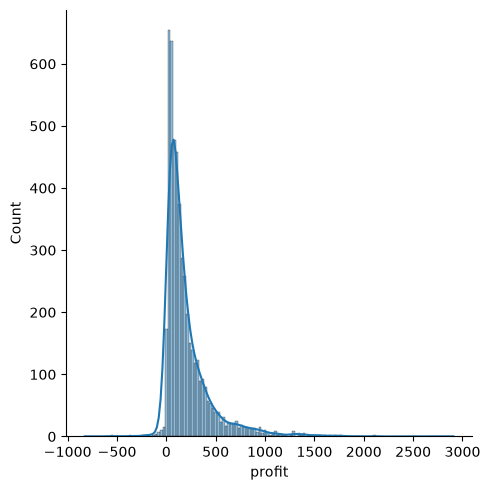

In [17]:
sns.displot(muestra_normalidad, kde=True)
# Si los datos no tienen forma de campana simétrica, comprueba que no son normales


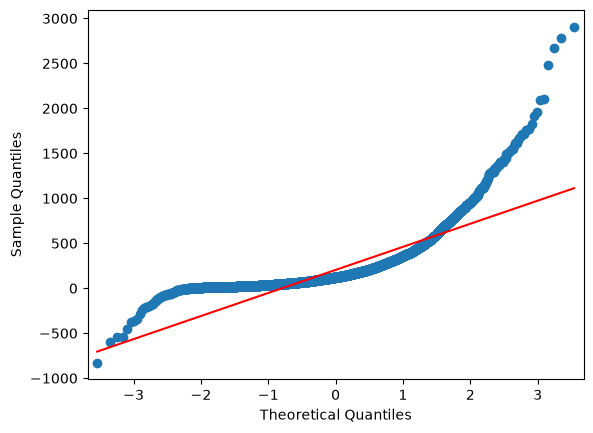

In [18]:
#Si los puntos se separan de la línea recta, se puede confirmar visualmente el resultado 
# de la prueba de normalidad
import statsmodels.api as sm

sm.qqplot(muestra_normalidad, line="s")
plt.show()

In [19]:
# Prueba de Levene: compara si la variabilidad (dispersión) de la ganancia es parecida
# entre los tres niveles de descuento.
grupos_descuento = [g["profit"].values for _, g in df.groupby("nivel_descuento", observed=True)]

estadistico_lev, p_valor_lev = stats.levene(*grupos_descuento)
print(f"Estadístico de Levene: {estadistico_lev:.4f}")
print(f"Valor p: {p_valor_lev:.2e}")

Estadístico de Levene: 2644.7097
Valor p: 0.00e+00


In [20]:
if p_valor_lev < alfa:
    print("\nConclusión: la variabilidad NO es parecida entre los grupos de descuento (p < 0.05).")
else:
    print("\nConclusión: la variabilidad puede considerarse parecida entre grupos.")


Conclusión: la variabilidad NO es parecida entre los grupos de descuento (p < 0.05).


<Axes: xlabel='nivel_descuento', ylabel='profit'>

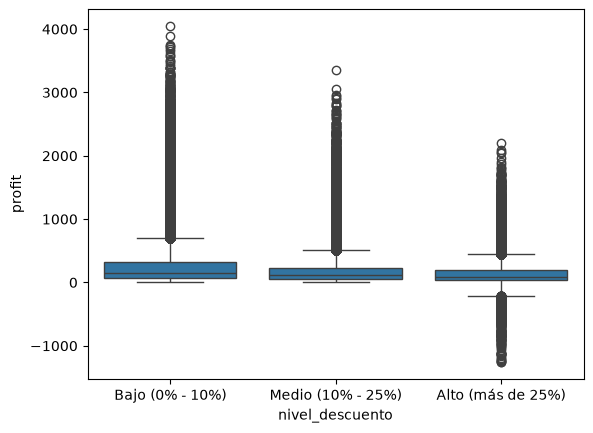

In [21]:
sns.boxplot(x="nivel_descuento", y="profit", data=df)

Como se puede evidenciar, la longitud tanto de los datos atipicos marcados en puntos y las lineas que componen las cjas de bigotes tienen longitudes totalemnte desiguales

**Decisión:** como la ganancia no es normal y la variabilidad no es igual entre los grupos
de descuento, se procede a usar pruebas **no paramétricas** para comparar los grupos, 
en lugar del clásico ANOVA (que exige normalidad y variabilidad pareja).

## 5. Pruebas estadísticas principales

### 5.1 ¿La ganancia cambia según el nivel de descuento? (prueba de Kruskal-Wallis)

La prueba de **Kruskal-Wallis** lo que hace es compara varios grupos (en este caso, descuento bajo, medio y alto) para ver si al menos uno de estos tiene valores típicamente distintos a los demás. Es la
versión no paramétrica del ANOVA.

In [22]:
estadistico_kw, p_valor_kw = stats.kruskal(*grupos_descuento)
print(f"Estadístico H de Kruskal-Wallis: {estadistico_kw:.4f}")
print(f"Valor p: {p_valor_kw:.2e}")

if p_valor_kw < alfa:
    print("\nConclusión: SÍ hay diferencias reales en la ganancia entre al menos dos niveles")
    print("de descuento (p < 0.05). La diferencia no se debe simplemente al azar.")
else:
    print("\nConclusión: no hay evidencia de diferencias reales entre los niveles de descuento.")

Estadístico H de Kruskal-Wallis: 12809.2693
Valor p: 0.00e+00

Conclusión: SÍ hay diferencias reales en la ganancia entre al menos dos niveles
de descuento (p < 0.05). La diferencia no se debe simplemente al azar.


In [23]:
# Prueba post-hoc de Dunn: Kruskal-Wallis solo nos dice que "hay diferencias en algún
# lugar", pero no cuáles pares de grupos son distintos entre sí. Para saber exactamente
# cuáles pares difieren, se usa esta prueba complementaria ("post-hoc" significa "después",
# porque se aplica después de confirmar que sí hay diferencias).
# Se usa un ajuste de Bonferroni para evitar falsas alarmas al hacer varias comparaciones seguidas.
posthoc = sp.posthoc_dunn(df, val_col="profit", group_col="nivel_descuento", p_adjust="bonferroni")
posthoc.round(4)


,Bajo (0% - 10%),Medio (10% - 25%),Alto (más de 25%)
Bajo (0% - 10%),1.0,0.0,0.0
Medio (10% - 25%),0.0,1.0,0.0
Alto (más de 25%),0.0,0.0,1.0


Al observar que todos los cruces entre grupos diferentes dan "0.0", la conclusión es contundente: 
Todos los niveles de descuento son totalmente diferentes entre sí en cuanto a sus ganancias.
Por lo tanto, la diferencia en las ganancias entre esos dos grupos es estadísticamente real y no se debe al azar.
El comportamiento del nivel Bajo, Medio y Alto es estadísticamente único en cada caso y se puede comprobar en los resultados del "1.0"

### 5.2 ¿La cantidad de unidades compradas afecta la ganancia? (Kruskal-Wallis)

Ahora comparamos la ganancia según cuántas unidades tenía la línea del pedido (1, 2, 3, 4 o 5).


In [24]:
grupos_cantidad = [g["profit"].values for _, g in df.groupby("quantity")]

estadistico_kw2, p_valor_kw2 = stats.kruskal(*grupos_cantidad)
print(f"Estadístico H de Kruskal-Wallis: {estadistico_kw2:.4f}")
print(f"Valor p: {p_valor_kw2:.2e}")

if p_valor_kw2 < alfa:
    print("\nConclusión: la ganancia SÍ cambia de forma real según la cantidad comprada (p < 0.05).")
else:
    print("\nConclusión: no hay evidencia de diferencia real según la cantidad comprada.")

Estadístico H de Kruskal-Wallis: 42309.4655
Valor p: 0.00e+00

Conclusión: la ganancia SÍ cambia de forma real según la cantidad comprada (p < 0.05).


<Axes: xlabel='quantity', ylabel='profit'>

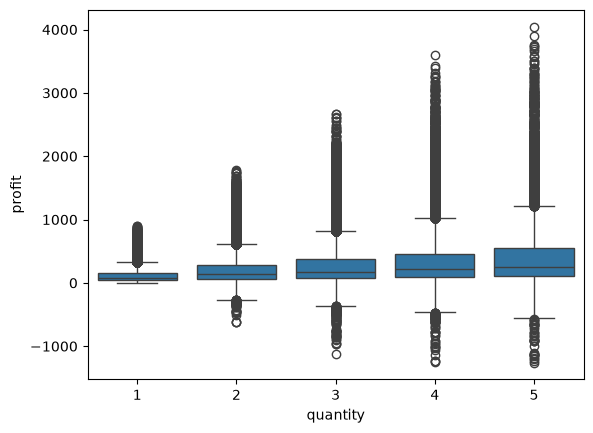

In [25]:
sns.boxplot(x="quantity", y="profit", data=df)

Visualmente se nota un patrón clarísimo y muy interesante para el negocio:
- Las cajas van escalando hacia arriba: se puede observar como los cualrtiles y la medianas a medida que la cantidad comprada aumenta de 1 a 5 unidades, esta tiende a crecer notablemente paso a paso. Esto demuestra de forma visual que a mayor cantidad de unidades en el pedido, la ganancia tiende a ser mayor.
- El crecimiento de los valores atípicos (outliers): Estas largas columnas de puntos negros muestran que las ganancias máximas potenciales (los picos que superan los 3,000 y 4,000 de ganancia) solo se alcanzan cuando el volumen de unidades por pedido es alto (cantidades de 3, 4 o 5). Sin mebargo es pertinente destacar que a partir de estas mismas cantidades es cuando se empiezan a identificar valores negativos atipicos lo que representan perdidas mayores a -1000 para el negocio

### 5.3 ¿A mayor descuento, menor margen de ganancia? (correlación de Spearman)

La **correlación** mide qué tan relacionadas están dos variables numéricas: si una sube, ¿la
otra tiende a subir, a bajar, o no tiene relación clara? 

El resultado (llamado "rho", ρ) va de -1 a 1:
- Cerca de **1**: cuando una variable sube, la otra también sube casi siempre.
- Cerca de **-1**: cuando una variable sube, la otra casi siempre baja.
- Cerca de **0**: no hay una relación clara entre las dos variables.

In [26]:
rho, p_valor_rho = stats.spearmanr(df["discount_percentage"], df["margen_ganancia"])
print(f"Coeficiente de correlación de Spearman (rho): {rho:.4f}")
print(f"Valor p: {p_valor_rho:.2e}")

if p_valor_rho < alfa:
    print("\nConclusión: la relación entre descuento y margen de ganancia es real y significativa (p < 0.05).")
else:
    print("\nConclusión: no hay evidencia de una relación real entre descuento y margen de ganancia.")

Coeficiente de correlación de Spearman (rho): -0.5142
Valor p: 0.00e+00

Conclusión: la relación entre descuento y margen de ganancia es real y significativa (p < 0.05).


Esto significa que las variables se mueven en direcciones opuestas. A mayor porcentaje de descuento, menor es el margen de ganancia (y viceversa).
Por otra parte al estar en torno al -0.51, demuestra que el impacto del descuento sobre el margen de ganancia es bastante marcado y visible.

<Axes: xlabel='discount_percentage', ylabel='margen_ganancia'>

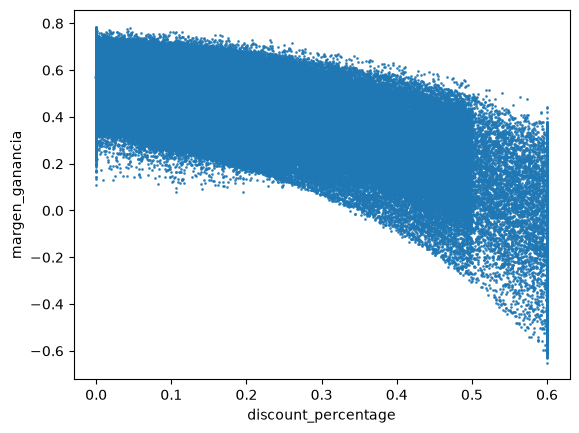

In [27]:
sns.regplot(x="discount_percentage", y="margen_ganancia", data=df, scatter_kws={'s': 1})


Al observar la gráfica de dispersión, se puedem extraer las siguientes conclusiones claves
- La nube de puntos tiene una caída diagonal muy clara. A medida que los porcentajes de descuento incrementan hacia la derecha en el eje horizontal (más descuento), los puntos se desploman verticalmente (menor margen).
-  El punto de quiebre crítico (20% - 30%): En el rango 0% y 20% de descuento, el margen de ganancia se mantiene saludable y bastante estable (entre el 20% y el 80%). Sin embargo, a partir del 0.30 (30% de descuento), la caída se vuelve drástica y en picada para el margen.
- Pérdidas garantizadas en descuentos altos: Cuando los descuentos superan el 0.4 (40%), una parte masiva de los puntos cae por debajo de cero en el eje vertical, alcanzando márgenes negativos de hasta -0.6 (-60%). Esto significa que con descuentos altos el negocio está perdiendo dinero por cada venta.

### 5.4 ¿Los pedidos se reparten de forma pareja entre 1, 2, 3, 4 y 5 unidades? (prueba de Chi-cuadrado)

Esta prueba compara cuántas líneas de venta hay realmente con  cada cantidad (1, 2, 3, 4 o 5
unidades). Es decir analiza cada refernecia del item de la venta y cuenta cauntas veces se adquirieron con frecuencia estos productos.

In [28]:
frecuencias_obs = df["quantity"].value_counts().sort_index()
chi2, p_valor_chi2 = stats.chisquare(frecuencias_obs)

print("Cantidad de líneas de venta según unidades compradas:")
print(frecuencias_obs)
print(f"\nEstadístico Chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_valor_chi2:.2e}")

if p_valor_chi2 < alfa:
    print("\nConclusión: las cantidades compradas NO se reparten de forma pareja (p < 0.05).")
else:
    print("\nConclusión: no hay evidencia de que la repartición sea distinta a la pareja.")

Cantidad de líneas de venta según unidades compradas:
quantity
1    165613
2     97944
3     74407
4     40381
5     19224
Name: count, dtype: int64

Estadístico Chi-cuadrado: 162802.6825
Valor p: 0.00e+00

Conclusión: las cantidades compradas NO se reparten de forma pareja (p < 0.05).


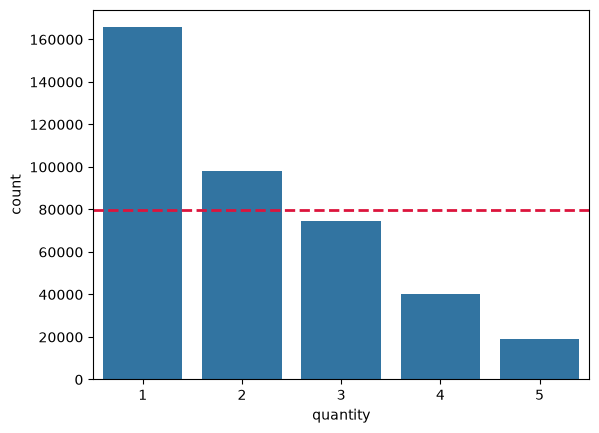

In [29]:
sns.countplot(x="quantity", data=df)
# Calcular y dibujar la línea de repartición pareja (promedio)
frecuencia_pareja = len(df) / df["quantity"].nunique()
plt.axhline(y=frecuencia_pareja, color="crimson", linestyle="--", linewidth=2, label="Repartición Pareja Teorica")


En este caso se evidencia como la pareja teorica son los 80 mil ventas que hace referencia al 0.5 del total y se comprueba que las barras difieren con gran diferencia de la linea roja.

## 6. Gráficos

### 6.1 Histograma: ¿cómo se distribuye la ganancia por línea de venta?

Considerando los calculos anteriores donde se identifican por lineas de venta de acuerdo a la cantidad de ventas de un mismo itema, se considera pertintente crear un **histograma** que agrupa los valores en barras para mostrar cuáles generan mas rentabilidad.

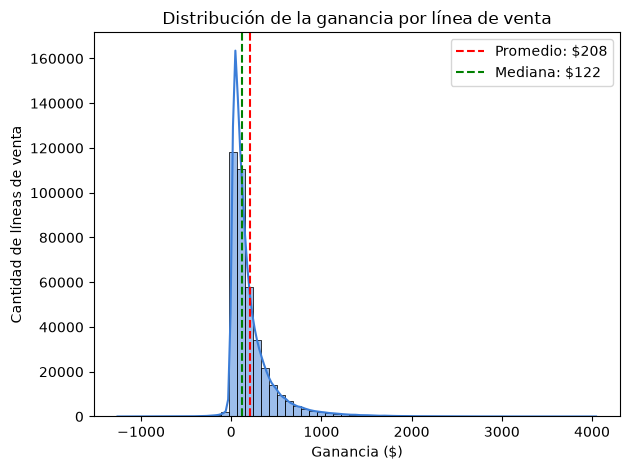

In [30]:
fig, ax = plt.subplots()
sns.histplot(df["profit"], bins=60, kde=True, color="#3B7DD8", ax=ax)
ax.axvline(df["profit"].mean(), color="red", linestyle="--", label=f"Promedio: ${df['profit'].mean():,.0f}")
ax.axvline(df["profit"].median(), color="green", linestyle="--", label=f"Mediana: ${df['profit'].median():,.0f}")
ax.set_title("Distribución de la ganancia por línea de venta")
ax.set_xlabel("Ganancia ($)")
ax.set_ylabel("Cantidad de líneas de venta")
ax.legend()
plt.tight_layout()
plt.show()

Se pueden realizar los siguientes analisis:
- La gran concentración cerca de cero (El pico más alto):El pico azul masivo acumulado entre $0 y $200 quiere decir que la inmensa mayoría de las ventas generan ganancias positivas pero muy bajas.Hay más de 160,000 líneas de venta concentradas en ese rango pequeño.
- Asimetría a la derecha (Cola larga positiva):El gráfico se estira mucho hacia la derecha (hasta $4,000). Esto significa que existen ventas atípicas excepcionales que dejan ganancias muy altas, pero son eventos poco comunes (por eso la barra azul se va haciendo plana y pequeña a medida que avanza).
- Pérdidas a la izquierda:La curva también se extiende hacia la izquierda de la línea del cero, llegando hasta casi -$1,000. Esto representa visualmente las órdenes donde el negocio perdió dinero (probablemente ligado a los descuentos altos previamente analizados).

### 6.2 Diagrama de cajas (boxplot): ganancia según nivel de descuento

Analizando el conjunto de datos creados al inicio del cuaderno, el cual era la clasificación de 3 niveles de descuento, se considero pertinente usar un **boxplot** (o "diagrama de cajas") ya que muestra, para cada grupo, dónde se concentra la mitad central de los datos (la caja), la mediana (línea dentro de la caja) y los valores atípicos (puntos sueltos muy alejados del resto, llamados **outliers**).

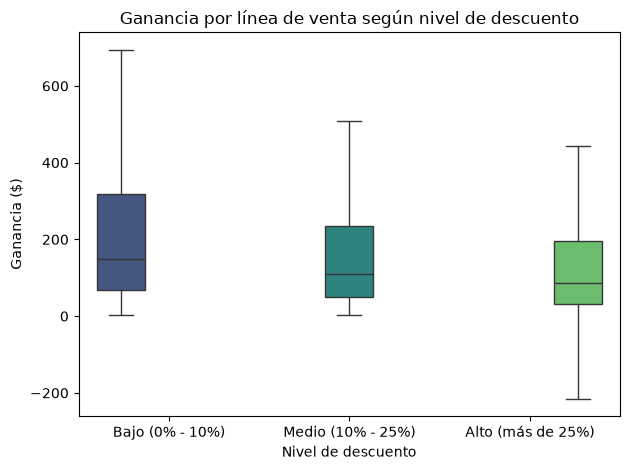

In [31]:
fig, ax = plt.subplots()
orden = ["Bajo (0% - 10%)", "Medio (10% - 25%)", "Alto (más de 25%)"]
sns.boxplot(data=df, x="nivel_descuento", y="profit", order=orden, hue="nivel_descuento",
            palette="viridis", legend=False, ax=ax, showfliers=False)
ax.set_title("Ganancia por línea de venta según nivel de descuento")
ax.set_xlabel("Nivel de descuento")
ax.set_ylabel("Ganancia ($)")
plt.tight_layout()
plt.show()

Para obtener esta verificación de datos se apartaron los datos atipicos para un mayor analisis, y entre las observaciones se puede resaltar:
- La ganancia cae a media que aumenta el descuento, ya que al analizar la mediana de cada caja, se puede identificar que esta va disminuyendo conforme aumenta el descuento
- Los tamaños de las cajas: La caja azul que discrimina el grupo de descuentos bajos del 0-10% se puede percibir como la mas grande de las 3, reflejando que al otrogar este descuento, la ganancia aumenta llegando hasta los 320 y es el el grupo con mayor cantidad de ganancias. Ahora bien, si se analiza la caja verde de los descuentos categorizados como altos, se puede identificar que no solo es el grupo que genera menor ganancia si no que tambien la venta mas alta casi es igual al promedio del grupo del descuento bajo del 0-10%
- Perdidas: La caja que representan el conjunto de descuentos denominado Alto, alcanza un limite inferior a cero llegando a -200, lo que permite identificar que este grupo de descuento es el menos rentable para el negocio.

### 6.3 Gráfico de área: ¿qué parte de la ganancia total viene de las líneas más rentables?

Este gráfico ordena las líneas de venta de mayor a menor ganancia y va acumulando el total. Así se puede ver, por ejemplo, qué porcentaje de líneas concentra la mayor parte de la ganancia total del negocio.

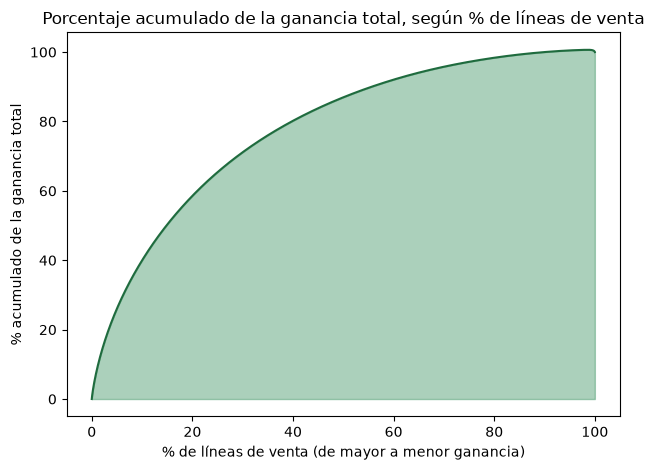

In [32]:
ganancia_ordenada = df["profit"].sort_values(ascending=False).reset_index(drop=True)
acumulado = ganancia_ordenada.cumsum()
porcentaje_lineas = (acumulado.index + 1) / len(acumulado) * 100
porcentaje_ganancia = acumulado / acumulado.iloc[-1] * 100

fig, ax = plt.subplots()
ax.fill_between(porcentaje_lineas, porcentaje_ganancia, color="#2E8B57", alpha=0.4)
ax.plot(porcentaje_lineas, porcentaje_ganancia, color="#1F6B3E")
ax.set_title("Porcentaje acumulado de la ganancia total, según % de líneas de venta")
ax.set_xlabel("% de líneas de venta (de mayor a menor ganancia)")
ax.set_ylabel("% acumulado de la ganancia total")
plt.tight_layout()
plt.show()

Este gráfico demuestra que la rentabilidad de la empresa depende fuertemente de pocas operaciones de alto valor. Si esas líneas clave fallaran o se les aplicara un descuento excesivo (como los que analizaste prveiamente), el impacto negativo en la ganancia total del negocio sería catastrófico.
Se puede evidenciar como apenas el 20% de las lineas de venta generan poco mas de la mitad del total de la utilidad del negocio

### 6.4 Gráfico de barras: ganancia total según cantidad de unidades compradas
Esta grafica representa que tanta ganancia se obtuvo al vender cierta cantidad de unidades que van de 1 a 5

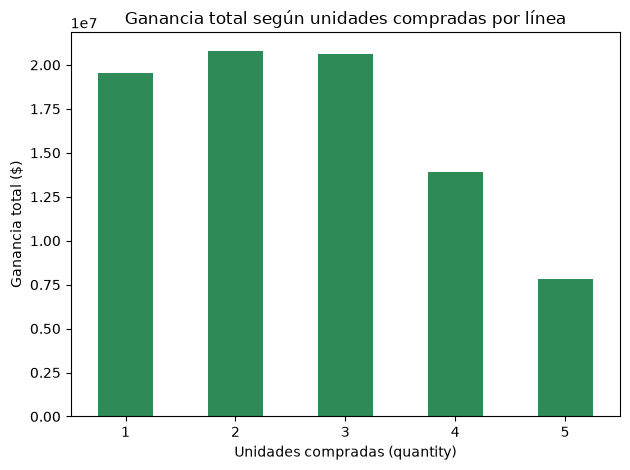

In [33]:
fig, ax = plt.subplots()
resumen_cantidad["ganancia_total"] = df.groupby("quantity")["profit"].sum()
resumen_cantidad["ganancia_total"].plot(kind="bar", color="#2E8B57", ax=ax)
ax.set_title("Ganancia total según unidades compradas por línea")
ax.set_xlabel("Unidades compradas (quantity)")
ax.set_ylabel("Ganancia total ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Se pueden identificar estos analisis
- Los pilares del negocio (1, 2 y 3 unidades): Cada uno de estos 3 grupos aporta mas de 20 millones a las ganancias globales. Esto es gracias a la cantidad de personas que acostumbran adquirir pequeñas cantidades de productos
- La caída drástica en volúmenes altos (4 y 5 unidades): Aunque los pedidos de 5 unidades generan un recaudo de caja eficaz y enorme, se logra identificar que en este negocio no es muy demandado por los clientes estas cantidades por lo tanto, el dinero total que ingresa por ellos es bajo en la escala del negocio.

## 7. Resumen de los hallazgos

- El archivo tiene **397.569 líneas de venta**, pertenecientes a **138.116 pedidos** distintos y
  **1.175 productos** diferentes. Cada una de las 397.569 lineas estan compuestas por la cantidad de items adquiridos por factura, ademas de eso se identifico que no hay datos vacíos ni filas duplicadas.
- Un **1,4% de las líneas** (5.426 de 397.569) tuvieron ganancia negativa (pérdida), es decir,
  el costo del producto superó lo que finalmente se cobró por él.
- La ganancia por línea de venta **no sigue una distribución normal** (prueba de Shapiro-Wilk,
  p < 0,05): hay muchas líneas de ganancia baja/media y pocas de ganancia muy alta.
- La variabilidad de la ganancia **no es igual** entre los niveles de descuento (prueba de
  Levene, p < 0,05), por lo que se usaron pruebas no paramétricas.
- Existen **diferencias reales** en la ganancia según el nivel de descuento aplicado (Kruskal-
  Wallis, p < 0,05); la prueba de Dunn muestra en qué pares de niveles se da esa diferencia.
- La cantidad de unidades compradas por línea **también se relaciona** con diferencias reales en
  la ganancia (Kruskal-Wallis, p < 0,05).
- El porcentaje de descuento y el margen de ganancia están **relacionados de forma significativa**
  (correlación de Spearman); sustentado con el signo y la fuerza (rho).
- Las cantidades compradas por línea (1 a 5 unidades) **no se reparten de forma pareja**
  (Chi-cuadrado, p < 0,05): comprar una sola unidad es, por mucho, lo más frecuente.

Estos hallazgos se explican con más detalle, en el informe académico adjunto.